# ENSDF Source Generation and Emission Calculation

This notebook demonstrates how to use the gov.bnl.nndc.ensdf package to:
1. Create radiation sources
2. Calculate emissions (beta, gamma, x-ray)
3. Compare results to reference data
4. Simulate source aging over time

The ENSDF package provides a comprehensive toolset for working with nuclear decay data in the Evaluated Nuclear Structure Data File format maintained by Brookhaven National Laboratory (BNL).

## 1. Setup and Initialization

First, we import required libraries and initialize the JVM to access Java classes through JPype.

In [1]:
# Initialize the JVM and import required libraries
import startJVM
import jpype
import jpype.imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Set up plotting style (optional)
try:
    plt.style.use('matplotlibrc')
    with plt.style.context('matplotlibrc'):
        plt.show()
except:
    pass  # If style file is not available, use default style

# Import Java classes for radiation physics and ENSDF data handling
from gov.llnl.rtk.physics import Nuclides, SourceImpl, Source, DecayCalculator, EmissionCalculator, Quantity
from gov.bnl.nndc.ensdf.decay import BNLDecayLibrary

# Additional classes for advanced usage
from java.nio.file import Paths
from gov.bnl.nndc.ensdf import EnsdfParser
from gov.bnl.nndc.ensdf.decay import SplitIsomers, SandiaFormatter
from gov.nist.physics.xray import NISTXrayLibrary
from java.util import ArrayList

/Users/hangal1/Documents/research/rda/radsim/proj-radsim/src


## 2. Understanding Nuclear Sources

Nuclear sources are characterized by:
- **Nuclide**: The specific isotope (e.g., Cs-137, Co-60)
- **Activity**: Rate of radioactive decay, measured in units like becquerel (Bq) or curie (Ci)
- **Decay modes**: The ways in which the nucleus decays (beta, gamma, alpha, etc.)

In this section, we'll create sources for common radionuclides used in calibration and research.

In [2]:
# Define activity using Quantity instead of ActivityUnit
activity_100Bq = Quantity.of(100, "Bq")  # 1 Becquerel = 1 decay per second
activity_94_7Bq = Quantity.of(94.7, "Bq")

# Create sources with specified activity
# SourceImpl.fromActivity(nuclide, activity) creates a source with specified activity

# Cs-137: Common calibration source, emits 662 keV gamma
Cs137 = SourceImpl.fromActivity(Nuclides.get("Cs137"), activity_100Bq)

# Ba-137m: Metastable daughter of Cs-137 decay
Ba137m = SourceImpl.fromActivity(Nuclides.get("Ba137m"), activity_94_7Bq)

# Co-60: Common industrial source, emits 1173 and 1332 keV gammas
Co60 = SourceImpl.fromActivity(Nuclides.get("Co60"), activity_100Bq)

# Na-22: Positron source, emits 511 keV annihilation gammas
Na22 = SourceImpl.fromActivity(Nuclides.get("Na22"), activity_100Bq)

# Ir-192: Industrial radiography source
Ir192 = SourceImpl.fromActivity(Nuclides.get("Ir192"), activity_100Bq)

# Create a source list containing the sources we want to analyze
# For this example, we'll focus on the Cs-137 -> Ba-137m decay chain
sourceList = ArrayList()
sourceList.add(Cs137)
sourceList.add(Ba137m)
# Uncomment to include additional sources
#sourceList.add(Co60)
#sourceList.add(Na22)
#sourceList.add(Ir192)

True

## 3. Loading Decay Data

The BNLDecayLibrary provides access to ENSDF decay data. It contains information about decay modes, energies, half-lives, and branching ratios for nuclides.

In [3]:
# Create a BNLDecayLibrary instance
bnllib = BNLDecayLibrary()

# Set the X-ray library
bnllib.setXrayLibrary(NISTXrayLibrary.getInstance())

# Load the ENSDF data file
# BNL2023.txt is a standard ENSDF format file with decay data
bnllib.loadFile(Paths.get("BNL2023.txt"))

# Initialize the emission calculator with our decay library
emcal = EmissionCalculator()
emcal.setDecayLibrary(bnllib)

## 4. Calculating Emissions

Now we'll use the emission calculator to determine all radiation emissions from our sources.

In [4]:
# Initialize data structures to store emission results
beta_record = {'E': [], 'I': []}   # Beta energies and intensities
gamma_record = {'E': [], 'I': []}  # Gamma energies and intensities
xray_record = {'E': [], 'I': []}   # X-ray energies and intensities

# Calculate emissions for our source list
# This returns an EmissionResults object containing all emissions
out = emcal.apply(sourceList)

### 4.1 Beta Emissions

Beta particles are electrons emitted from the nucleus during beta decay. They have a continuous energy spectrum up to a maximum endpoint energy.

In [5]:
# Extract beta emissions
for emission in out.getBetas():
    # Get energy in keV
    e_e = emission.getEnergy().getValue()
    
    # Get intensity (emissions per decay)
    e_i = emission.getIntensity().getValue()
    
    # Store values for plotting
    beta_record['E'].append(e_e)
    beta_record['I'].append(e_i)
    
    # Print details including forbiddenness (indicates transition type)
    print("Beta-: ", e_e, e_i, emission.getForbiddenness())

Beta-:  514.03 94.6994507431857 1U
Beta-:  892.1300000000001 0.000579996636019511 2U
Beta-:  1176.0 5.29996926017829 


### 4.2 Gamma Emissions

Gamma rays are high-energy photons emitted when a nucleus transitions from an excited state to a lower energy state.

In [6]:
# Extract gamma emissions
for emission in out.getGammas():
    e_e = emission.getEnergy().getValue()
    e_i = emission.getIntensity().getValue()
    gamma_record['E'].append(e_e)
    gamma_record['I'].append(e_i)
    print("Gamma: ", e_e, e_i)

Gamma:  283.5 0.00058
Gamma:  661.657 85.1353


### 4.3 X-ray Emissions

X-rays are emitted during electron capture or internal conversion when atomic electrons reorganize to fill vacancies.

In [7]:
# Extract X-ray emissions
for emission in out.getXrays():
    e_e = emission.getEnergy().getValue()
    e_i = emission.getIntensity().getValue()
    xray_record['E'].append(e_e)
    xray_record['I'].append(e_i)
    
    # Print details including the transition name (e.g., K-L2 indicates an electron
    # filling a K-shell vacancy from the L2 shell)
    print("Xray: ", e_e, e_i, emission.getName())

Xray:  3.9539999999999997 0.0039861972746856 L3-M1
Xray:  4.331 0.0031580679094847996 L2-M1
Xray:  4.4513 0.011125309256458802 L3-M4
Xray:  4.4665 0.099945988578384 L3-M5
Xray:  4.8283000000000005 0.11481044145292799 L2-M4
Xray:  4.852 0.021539274484727998 L1-M2
Xray:  4.926 0.03625882354068 L1-M3
Xray:  4.9935 0.0007505941455167998 L3-N1
Xray:  5.1544 0.020326867063932 L3-N4,5
Xray:  5.5314 0.016763168949696 L2-N4
Xray:  5.796999999999999 0.0065265809393616 L1-N2
Xray:  5.8104 0.008654943631152 L1-N3
Xray:  31.452000000000005 0.0038779479452758564 K-L1
Xray:  31.817 2.0544464746672535 K-L2
Xray:  32.194 3.7840987830075132 K-L3
Xray:  36.304 0.3555689274899637 K-M2
Xray:  36.378 0.6867383620253872 K-M3
Xray:  36.645300000000006 0.010002101780727657 K-M4,5
Xray:  37.249 0.2648869864347053 K-N2,3
Xray:  37.3484 0.0027972035398852813 K-N4,5


## 5. Visualizing and Validating Results

Let's plot our calculated emission data and compare it with reference data from the Nuclear Data Tables (NuDat).

### 5.1 Beta Spectrum Comparison

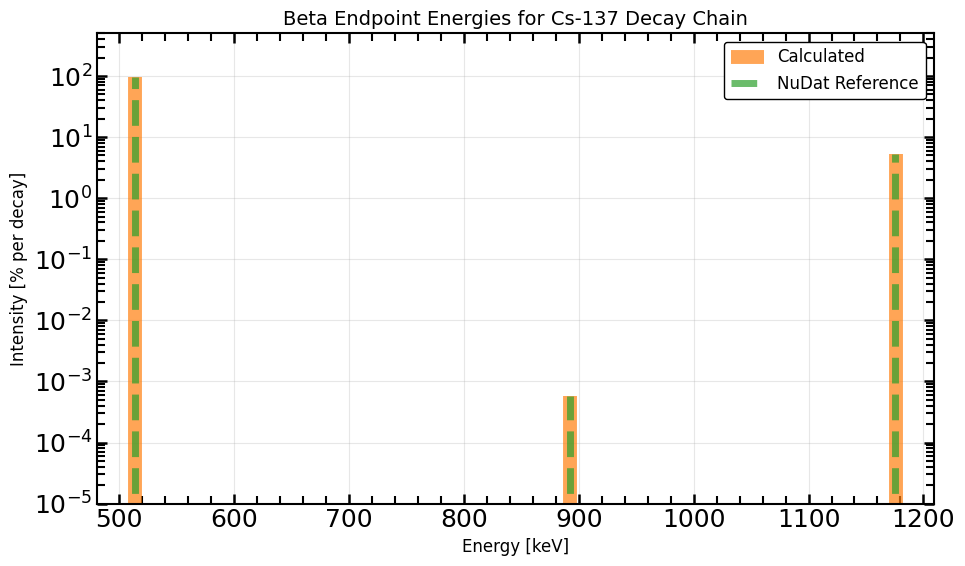

In [8]:
# NuDat reference data for beta emissions
E_beta_ref = [513.97, 892.13, 1175.63]  # keV
I_beta_ref = [94.70, 5.8E-4, 5.30]      # intensity per decay (%)

# Plot calculated vs. reference data
plt.figure(figsize=(10, 6))
plt.vlines(beta_record['E'], ymin=0, ymax=beta_record['I'], 
           linewidth=10, color='C1', label="Calculated", alpha=0.7)
plt.vlines(E_beta_ref, ymin=0, ymax=I_beta_ref, 
           linewidth=5, linestyle='--', color='C2', label="NuDat Reference", alpha=0.7)

# Add labels and formatting
plt.xlabel('Energy [keV]', fontsize=12)
plt.ylabel('Intensity [% per decay]', fontsize=12)
plt.yscale('log')
plt.ylim(ymin=1E-5, ymax=500)
plt.title('Beta Endpoint Energies for Cs-137 Decay Chain', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 5.2 Gamma Spectrum Comparison

The most prominent gamma emission in the Cs-137 decay chain is the 661.7 keV gamma from Ba-137m.

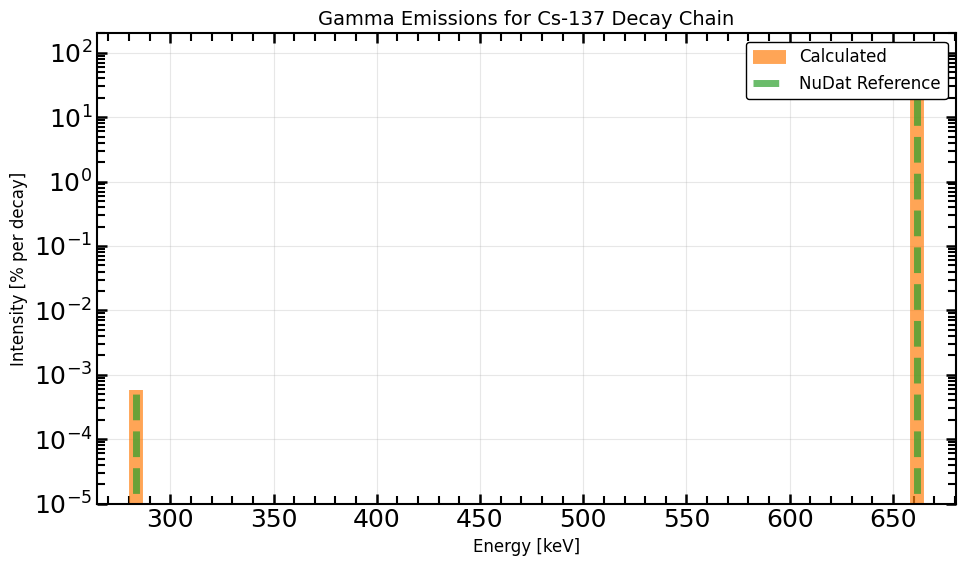

In [9]:
# NuDat reference data for gamma emissions
E_gamma_ref = [283.5, 661.657]  # keV
I_gamma_ref = [5.8E-4, 85.10]   # intensity per decay (%)

# Plot calculated vs. reference data
plt.figure(figsize=(10, 6))
plt.vlines(gamma_record['E'], ymin=0, ymax=gamma_record['I'], 
           linewidth=10, color='C1', label="Calculated", alpha=0.7)
plt.vlines(E_gamma_ref, ymin=0, ymax=I_gamma_ref, 
           linewidth=5, linestyle='--', color='C2', label="NuDat Reference", alpha=0.7)

# Add labels and formatting
plt.xlabel('Energy [keV]', fontsize=12)
plt.ylabel('Intensity [% per decay]', fontsize=12)
plt.yscale('log')
plt.ylim(ymin=1E-5, ymax=200)
plt.title('Gamma Emissions for Cs-137 Decay Chain', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 X-ray Spectrum Comparison

X-rays occur at characteristic energies based on the electron shell transitions in the daughter nuclide.

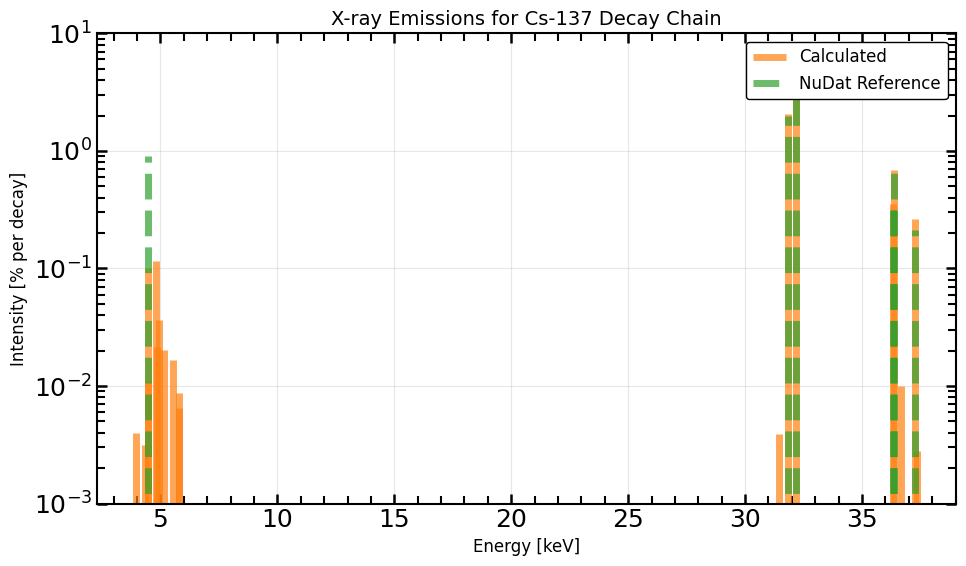

In [10]:
# NuDat reference data for X-ray emissions
E_xray_ref = [4.47, 31.817, 32.194, 36.304, 36.378, 37.255]  # keV
I_xray_ref = [0.91, 1.99, 3.64, 0.348, 0.672, 0.213]         # intensity per decay (%)

# Plot calculated vs. reference data
plt.figure(figsize=(10, 6))
plt.vlines(xray_record['E'], ymin=0, ymax=xray_record['I'], 
           linewidth=5, color='C1', label="Calculated", alpha=0.7)
plt.vlines(E_xray_ref, ymin=0, ymax=I_xray_ref, 
           linewidth=5, linestyle='--', color='C2', label="NuDat Reference", alpha=0.7)

# Add labels and formatting
plt.xlabel('Energy [keV]', fontsize=12)
plt.ylabel('Intensity [% per decay]', fontsize=12)
plt.yscale('log')
plt.ylim(ymin=1E-3, ymax=10)
plt.title('X-ray Emissions for Cs-137 Decay Chain', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 6. Simulating Source Aging Over Time

Radioactive sources decay over time according to their half-lives. We can use the DecayCalculator to predict how a source will evolve.

In [11]:
# Create a decay calculator with our library
dc = DecayCalculator()
dc.setDecayLibrary(bnllib)

# Create a source list with just Cs-137
sourceList = ArrayList()
sourceList.add(Cs137)

# Age the source for 10,000 seconds and see what happens
aged_sourceList = dc.age(sourceList, 10000)

### 6.1 Decay Curve Visualization

Now we'll simulate aging over a wide range of times and plot the decay curves.

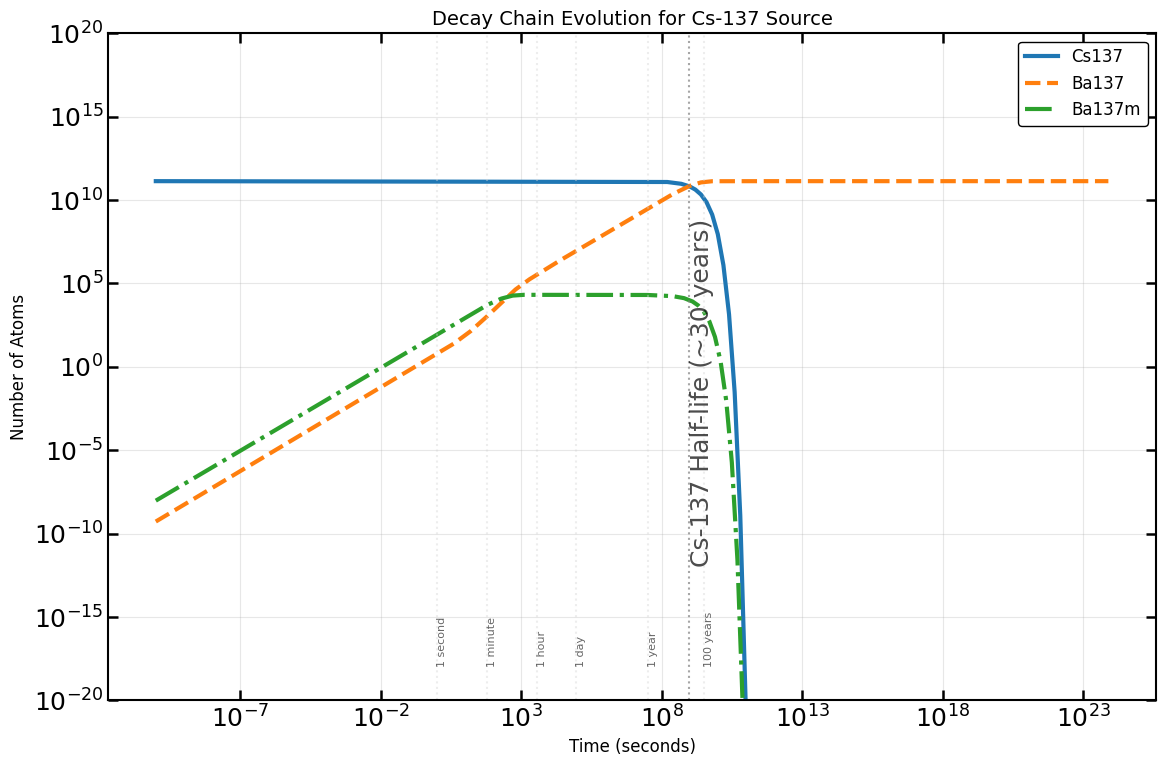

In [17]:
# Generate a logarithmic time scale from 10^-10 to 10^24 seconds
# This range covers everything from nanoseconds to billions of years
t = 10**np.arange(-10, 24, 0.1)
out = []

# Calculate the source composition at each time point
for i in t:
    result = dc.age(sourceList, i)
    out.append([j.getAtoms() for j in result])

# Line styles for different nuclides
ls = ['-', '--', '-.']

# Convert results to numpy array for easier plotting
out = np.array(out)

# Plot the decay curves
plt.figure(figsize=(12, 8))

# Plot each nuclide in the decay chain
for i in range(len(aged_sourceList)):
    plt.plot(t, np.array(out[:,i]), 
             linestyle=ls[i % len(ls)], linewidth=3, 
             label=str(aged_sourceList[i].getNuclide()))

# Annotate key time periods for context
half_life_cs137 = 30.08 * 365.25 * 24 * 3600  # ~30 years in seconds
plt.axvline(half_life_cs137, color='gray', linestyle=':', alpha=0.7)
plt.text(half_life_cs137 * 1.1, 1e-12, 'Cs-137 Half-life (~30 years)', 
         rotation=90, va='bottom', alpha=0.7)

# Add labels and formatting
plt.legend(fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-20, 1e20)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Number of Atoms', fontsize=12)
plt.title('Decay Chain Evolution for Cs-137 Source', fontsize=14)
plt.grid(True, which='both', alpha=0.3)

# Add time scale reference markers
time_markers = {
    1: '1 second',
    60: '1 minute',
    3600: '1 hour',
    86400: '1 day',
    31557600: '1 year',
    31557600*100: '100 years'
}

for seconds, label in time_markers.items():
    plt.axvline(seconds, color='lightgray', linestyle=':', alpha=0.4)
    plt.text(seconds, 1e-18, label, rotation=90, va='bottom', alpha=0.6, fontsize=8)

plt.tight_layout()
plt.show()

## 7. Advanced Usage: Direct Access to ENSDF Data

For more specialized applications, we can directly access the ENSDF data structures.

In [13]:
# Parse an ENSDF file directly to access the raw data records
def explore_ensdf_records(file_path):
    # Parse the ENSDF file
    records = EnsdfParser.parseFile(Paths.get(file_path))
    print(f"Found {len(records)} ENSDF datasets in file")
    
    # Examine the first record in detail
    if records:
        dataset = records[0]
        print(f"\nDataset identification: {dataset.identification.DSID}")
        print(f"Target nuclide: {dataset.identification.target}")
        print(f"Publication date: {dataset.identification.DATE}")
        
        # Print levels information
        print(f"\nEnergy levels: {len(dataset.levels)}")
        for i, level in enumerate(dataset.levels[:5]):  # Show first 5 levels
            print(f"  Level {i}: Energy = {level.E} keV, Spin/Parity = {level.J}, Half-life = {level.T}")
            
        # Print gamma transitions for the first level (if any)
        if dataset.levels and dataset.levels[0].gamma:
            print(f"\nGamma transitions from first level:")
            for i, gamma in enumerate(dataset.levels[0].gamma[:3]):  # Show first 3 gammas
                print(f"  Gamma {i}: Energy = {gamma.E} keV, Intensity = {gamma.RI}")
    
    return records

# Uncomment to explore ENSDF records directly
# records = explore_ensdf_records("BNL2023.txt")

## 8. Conclusion

The gov.bnl.nndc.ensdf package provides powerful capabilities for:

1. **Data Access**: Reading and parsing ENSDF format nuclear data
2. **Source Modeling**: Creating radiation sources with defined activities
3. **Emission Calculation**: Computing beta, gamma, and x-ray emissions
4. **Decay Simulation**: Modeling how sources evolve over time

These tools are essential for radiation transport simulations, detector response modeling, and other nuclear applications.

## 9. Further Reading

- [ENSDF Format Documentation](https://www.nndc.bnl.gov/ensdf/ensdf-doc.pdf)
- [BNL Nuclear Data Center](https://www.nndc.bnl.gov/)
- [Chart of Nuclides](https://www.nndc.bnl.gov/nudat2/)